<a href="https://colab.research.google.com/github/palakbhatt1/fuel-price-prediction-india-multimodel-analysis/blob/main/petrol_price_direction_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Petrol Price Change Direction Using Macroeconomic Indicators

## Introduction
This project aims to predict the direction of petrol price changes using various macroeconomic indicators. We analyze the relationship between petrol prices and key factors such as USD-INR exchange rates, Brent oil prices, and excise duty to develop a predictive model.

### Project Objectives
1. Analyze historical petrol price trends and their relationships with macroeconomic indicators
2. Identify key factors influencing petrol price changes
3. Develop a model to predict the direction of price changes
4. Evaluate model performance and provide insights

## Table of Contents
1. Data Loading and Initial Exploration
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Conclusions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from graphviz import Digraph
from sklearn.model_selection import train_test_split

In [ ]:
dot = Digraph()
dot.node('start','Start')


## 1. Data Loading and Initial Exploration

Let's load our dataset and perform initial exploration to understand its structure and contents.

In [ ]:
pp_df = pd.read_csv("https://raw.githubusercontent.com/Harshs-06/Datasets_MachineLearning/refs/heads/main/Final_Combined_Data_With_Excise.csv")


In [ ]:
print("Dataset Shape:", pp_df.shape)

Dataset Shape: (1803, 18)


In [ ]:
print("\nDataset Info:")
pp_df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1803 entries, 0 to 1802
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        1803 non-null   object 
 1   Petrol_Price_INR            1803 non-null   object 
 2   PriceChange                 1803 non-null   float64
 3   ChangeDirection             1803 non-null   object 
 4   USD_INR_Price               1803 non-null   float64
 5   USD_INR_Open                1803 non-null   float64
 6   USD_INR_High                1803 non-null   float64
 7   USD_INR_Low                 1803 non-null   float64
 8   USD_INR_Vol                 0 non-null      float64
 9   USD_INR_Change_Percent      1803 non-null   object 
 10  Brent_Oil_Price_USD         1803 non-null   float64
 11  Brent_Oil_Open              1803 non-null   float64
 12  Brent_Oil_High              1803 non-null   float64
 13  Brent_Oil_Low     

In [ ]:
pp_df.describe()

,PriceChange,USD_INR_Price,USD_INR_Open,USD_INR_High,USD_INR_Low,USD_INR_Vol,Brent_Oil_Price_USD,Brent_Oil_Open,Brent_Oil_High,Brent_Oil_Low,Excise_Amount_Rs_Per_Litre
count,1803.000000,1803.000000,1803.000000,1803.000000,1803.000000,0.0,1803.000000,1803.000000,1803.000000,1803.000000,1803.000000
mean,0.020327,76.669680,76.674011,76.814322,76.547984,NaN,76.390738,76.398907,77.482879,75.239384,21.037410
std,0.566911,8.719286,8.722747,8.708944,8.734679,NaN,16.251288,16.226921,16.597855,15.857335,4.497747
min,-8.560000,39.660000,39.570000,39.710000,39.410000,NaN,25.020000,25.220000,25.450000,24.800000,8.000000
25%,0.000000,70.970500,70.967500,71.160000,70.808500,NaN,66.550000,66.545000,67.180000,65.695000,19.900000
50%,0.000000,81.280000,81.227000,81.527000,81.105000,NaN,76.610000,76.770000,77.630000,75.510000,19.900000
75%,0.000000,83.322000,83.343500,83.426000,83.262500,NaN,84.800000,84.890000,85.665000,83.790000,19.900000
max,7.540000,87.627000,87.994000,87.997000,87.429000,NaN,137.690000,138.760000,139.260000,132.500000,34.900000


## 2. Data Preprocessing

Before we proceed with analysis, let's clean and prepare our data:
1. Convert date column to proper datetime format
2. Clean the petrol price column by removing the ₹ symbol
3. Handle any missing values
4. Create additional features if needed

In [ ]:
pp_df.head()

,Date,Petrol_Price_INR,PriceChange,ChangeDirection,USD_INR_Price,USD_INR_Open,USD_INR_High,USD_INR_Low,USD_INR_Vol,USD_INR_Change_Percent,Brent_Oil_Price_USD,Brent_Oil_Open,Brent_Oil_High,Brent_Oil_Low,Brent_Oil_Vol,Brent_Oil_Change_Percent,Excise_Tax_Type,Excise_Amount_Rs_Per_Litre
0,2002-08-16,₹ 29,-0.18,down,48.55,48.63,48.635,48.530,NaN,-0.06%,27.00,26.69,27.20,26.53,37.50K,0.75%,Basic Excise Duty,9.0
1,2002-09-16,₹ 29.66,0.46,up,48.38,48.46,48.470,48.350,NaN,-0.08%,28.52,28.68,28.68,28.21,31.99K,0.74%,Basic Excise Duty,9.0
2,2002-10-01,₹ 29.91,0.25,up,48.34,48.39,48.430,48.305,NaN,-0.02%,29.01,28.85,29.39,28.70,37.89K,0.90%,Basic Excise Duty,9.0
3,2002-10-17,₹ 30.24,0.33,up,48.37,48.41,48.452,48.330,NaN,0.02%,27.97,27.68,28.09,27.55,41.70K,-2.13%,Basic Excise Duty,9.0
4,2002-11-01,₹ 30.26,0.02,up,48.31,48.34,48.400,48.300,NaN,-0.06%,25.41,25.77,26.05,25.40,40.69K,-1.21%,Basic Excise Duty,9.0


In [ ]:
pp_df['Date'] = pd.to_datetime(pp_df['Date'])

In [ ]:
pp_df['Petrol_Price_INR'] = pp_df['Petrol_Price_INR'].str.replace('₹', '').str.strip().astype(float)

In [ ]:
print(pp_df.isnull().sum())

Date                             0
Petrol_Price_INR                 0
PriceChange                      0
ChangeDirection                  0
USD_INR_Price                    0
USD_INR_Open                     0
USD_INR_High                     0
USD_INR_Low                      0
USD_INR_Vol                   1803
USD_INR_Change_Percent           0
Brent_Oil_Price_USD              0
Brent_Oil_Open                   0
Brent_Oil_High                   0
Brent_Oil_Low                    0
Brent_Oil_Vol                    0
Brent_Oil_Change_Percent         0
Excise_Tax_Type                  0
Excise_Amount_Rs_Per_Litre       0
dtype: int64


In [ ]:
pp_df['USD_INR_Change_Percent'] = pp_df['USD_INR_Change_Percent'].str.replace('%', '').astype(float)
pp_df['Brent_Oil_Change_Percent'] = pp_df['Brent_Oil_Change_Percent'].str.replace('%', '').astype(float)

In [ ]:
pp_df.dropna(axis=1,inplace=True)

In [ ]:
def convert_volume(val):
    if isinstance(val, str):
        if 'K' in val:
            return float(val.replace('K', '')) * 1_000
        elif 'M' in val:
            return float(val.replace('M', '')) * 1_000_000
    return val

pp_df['Brent_Oil_Vol'] = pp_df['Brent_Oil_Vol'].apply(convert_volume)

In [ ]:
pp_df['Excise_Tax_Type'] = pp_df['Excise_Tax_Type'].map({
    'Basic Excise Duty': 0,
    'Total Central Excise Duty': 1
})

In [ ]:
pp_df['ChangeDirection'] = pp_df['ChangeDirection'].map({
    'down': 0,
    'up': 1
})

In [ ]:
pp_df['Year'] = pp_df['Date'].dt.year
pp_df['Month'] = pp_df['Date'].dt.month
pp_df['Day'] = pp_df['Date'].dt.day



In [ ]:
pp_df.columns

Index(['Date', 'Petrol_Price_INR', 'PriceChange', 'ChangeDirection',
       'USD_INR_Price', 'USD_INR_Open', 'USD_INR_High', 'USD_INR_Low',
       'USD_INR_Change_Percent', 'Brent_Oil_Price_USD', 'Brent_Oil_Open',
       'Brent_Oil_High', 'Brent_Oil_Low', 'Brent_Oil_Vol',
       'Brent_Oil_Change_Percent', 'Excise_Tax_Type',
       'Excise_Amount_Rs_Per_Litre', 'Year', 'Month', 'Day'],
      dtype='object')

In [ ]:
cols = ['Year', 'Month', 'Day'] + [col for col in pp_df.columns if col not in ['Year', 'Month', 'Day']]
pp_df = pp_df[cols]

In [ ]:
pp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1803 entries, 0 to 1802
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Year                        1803 non-null   int32         
 1   Month                       1803 non-null   int32         
 2   Day                         1803 non-null   int32         
 3   Date                        1803 non-null   datetime64[ns]
 4   Petrol_Price_INR            1803 non-null   float64       
 5   PriceChange                 1803 non-null   float64       
 6   ChangeDirection             1803 non-null   int64         
 7   USD_INR_Price               1803 non-null   float64       
 8   USD_INR_Open                1803 non-null   float64       
 9   USD_INR_High                1803 non-null   float64       
 10  USD_INR_Low                 1803 non-null   float64       
 11  USD_INR_Change_Percent      1803 non-null   float64     

In [ ]:
pp_df['Oil_Price_MA_7'] = pp_df['Brent_Oil_Price_USD'].rolling(window=7).mean()
pp_df['USD_INR_MA_7'] = pp_df['USD_INR_Price'].rolling(window=7).mean()

In [ ]:
pp_df['Oil_Price_Diff'] = pp_df['Brent_Oil_Price_USD'].diff(7)
pp_df['USD_INR_Diff'] = pp_df['USD_INR_Price'].diff(7)

In [ ]:
pp_df['oil_price_change'] = pp_df['Brent_Oil_Price_USD'].pct_change()
pp_df['usd_inr_change'] = pp_df['USD_INR_Price'].pct_change()

In [ ]:
pp_df['Excise_Percentage'] = pp_df['Excise_Amount_Rs_Per_Litre'] / pp_df['Petrol_Price_INR'] * 100

In [ ]:
pp_df = pp_df.bfill()

In [ ]:
pp_df

,Year,Month,Day,Date,Petrol_Price_INR,PriceChange,ChangeDirection,USD_INR_Price,USD_INR_Open,USD_INR_High,...,Brent_Oil_Change_Percent,Excise_Tax_Type,Excise_Amount_Rs_Per_Litre,Oil_Price_MA_7,USD_INR_MA_7,Oil_Price_Diff,USD_INR_Diff,oil_price_change,usd_inr_change,Excise_Percentage
0,2002,8,16,2002-08-16,29.00,-0.18,0,48.550,48.630,48.635,...,0.75,0,9.0,28.620000,48.262857,-1.98,-1.220,0.056296,-0.003502,31.034483
1,2002,9,16,2002-09-16,29.66,0.46,1,48.380,48.460,48.470,...,0.74,0,9.0,28.620000,48.262857,-1.98,-1.220,0.056296,-0.003502,30.343898
2,2002,10,1,2002-10-01,29.91,0.25,1,48.340,48.390,48.430,...,0.90,0,9.0,28.620000,48.262857,-1.98,-1.220,0.017181,-0.000827,30.090271
3,2002,10,17,2002-10-17,30.24,0.33,1,48.370,48.410,48.452,...,-2.13,0,9.0,28.620000,48.262857,-1.98,-1.220,-0.035850,0.000621,29.761905
4,2002,11,1,2002-11-01,30.26,0.02,1,48.310,48.340,48.400,...,-1.21,0,9.0,28.620000,48.262857,-1.98,-1.220,-0.091527,-0.001240,29.742234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1798,2025,4,30,2025-04-30,94.81,0.00,0,84.599,85.220,85.268,...,-1.76,1,34.9,64.761429,85.031286,-3.75,-0.786,0.000000,0.000000,36.810463
1799,2025,5,1,2025-05-01,94.81,0.00,0,84.590,84.609,84.745,...,-1.57,1,34.9,64.084286,84.917714,-4.74,-0.795,-0.015684,-0.000106,36.810463
1800,2025,5,1,2025-05-01,94.81,0.00,0,84.590,84.609,84.745,...,-1.57,1,34.9,63.551429,84.835857,-3.73,-0.573,0.000000,0.000000,36.810463
1801,2025,5,2,2025-05-02,94.81,0.00,0,84.527,84.657,84.685,...,-1.35,1,34.9,62.898571,84.745000,-4.57,-0.636,-0.013520,-0.000745,36.810463


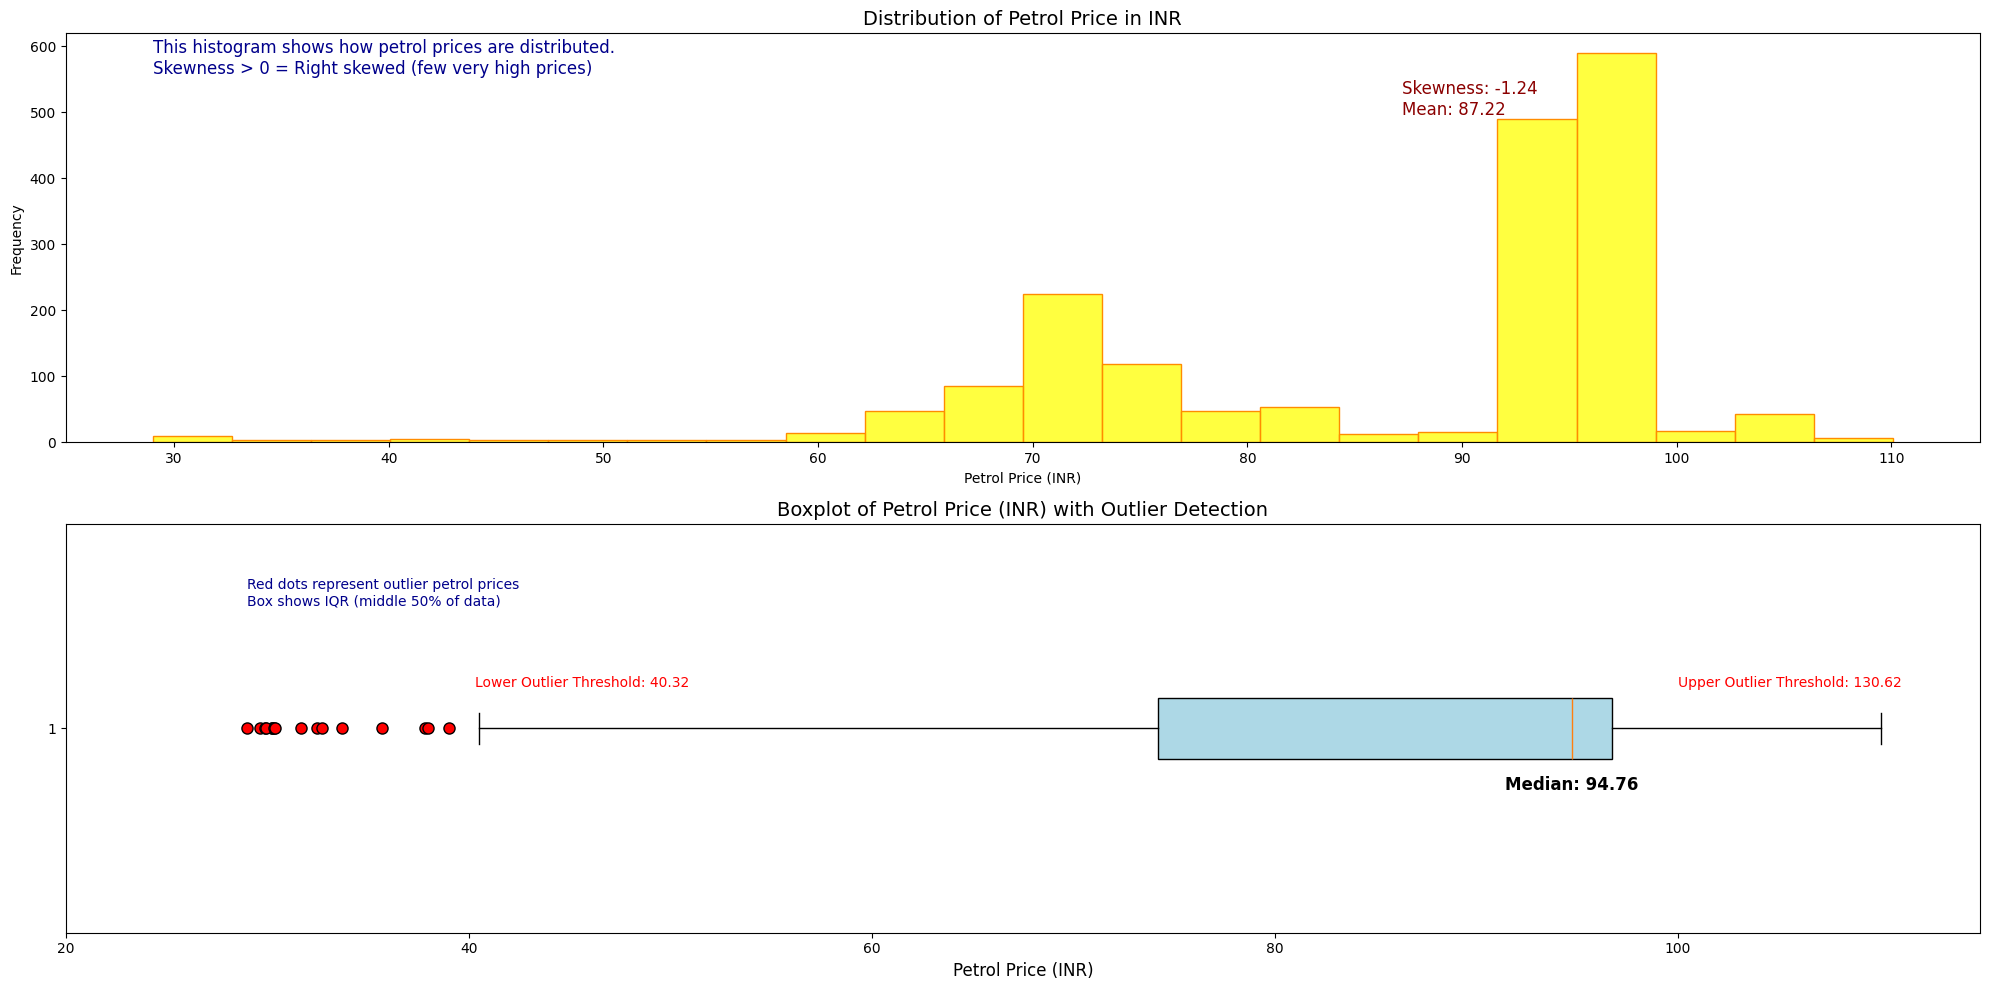

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(2,1,1)
# Histogram
sns.histplot(data=pp_df,x='Petrol_Price_INR',color='yellow',edgecolor='darkorange')

# Title & labels
plt.title("Distribution of Petrol Price in INR", fontsize=14)
plt.xlabel("Petrol Price (INR)")
plt.ylabel("Frequency")
# plt.xlim(20,115)
from scipy.stats import skew
skewness = skew(pp_df['Petrol_Price_INR'].dropna())
plt.text(pp_df['Petrol_Price_INR'].mean(), plt.ylim()[1]*0.8,
         f"Skewness: {skewness:.2f}\nMean: {pp_df['Petrol_Price_INR'].mean():.2f}",
         fontsize=12, color='darkred')


plt.text(pp_df['Petrol_Price_INR'].min(), plt.ylim()[1]*0.9,
         "This histogram shows how petrol prices are distributed.\nSkewness > 0 = Right skewed (few very high prices)",
         fontsize=12, color='darkblue')
plt.subplot(2,1,2)
plt.xlim(20,115)




plt.boxplot(pp_df['Petrol_Price_INR'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            flierprops=dict(marker='o', markerfacecolor='red', markersize=8))


plt.title("Boxplot of Petrol Price (INR) with Outlier Detection", fontsize=14)
plt.xlabel("Petrol Price (INR)", fontsize=12)


Q1 = pp_df['Petrol_Price_INR'].quantile(0.25)
Q3 = pp_df['Petrol_Price_INR'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plt.text(lower_bound, 1.1, f'Lower Outlier Threshold: {lower_bound:.2f}', color='red')
plt.text(100, 1.1, f'Upper Outlier Threshold: {upper_bound:.2f}', color='red')
plt.text(pp_df['Petrol_Price_INR'].median(), 0.85, f'Median: {pp_df["Petrol_Price_INR"].median():.2f}',
         ha='center', fontsize=12, fontweight='bold')


plt.text(pp_df['Petrol_Price_INR'].min(), 1.3,
         "Red dots represent outlier petrol prices\nBox shows IQR (middle 50% of data)",
         fontsize=10, color='darkblue')


plt.tight_layout()
plt.show()

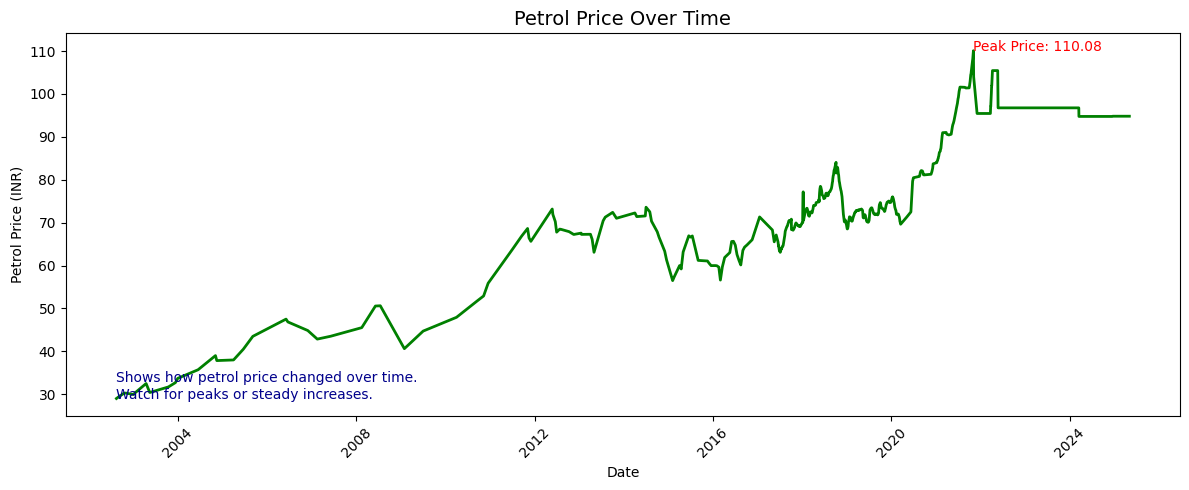

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(pp_df['Date'], pp_df['Petrol_Price_INR'], color='green', linewidth=2)
plt.title("Petrol Price Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Petrol Price (INR)")
plt.xticks(rotation=45)

# Annotate a specific point (e.g., max)
max_price = pp_df['Petrol_Price_INR'].max()
max_date = pp_df[pp_df['Petrol_Price_INR'] == max_price]['Date'].values[0]
plt.text(max_date, max_price, f'Peak Price: {max_price}', color='red', fontsize=10)

plt.text(pp_df['Date'].values[0], pp_df['Petrol_Price_INR'].min(),
         "Shows how petrol price changed over time.\nWatch for peaks or steady increases.",
         fontsize=10, color='darkblue')

plt.tight_layout()
plt.show()

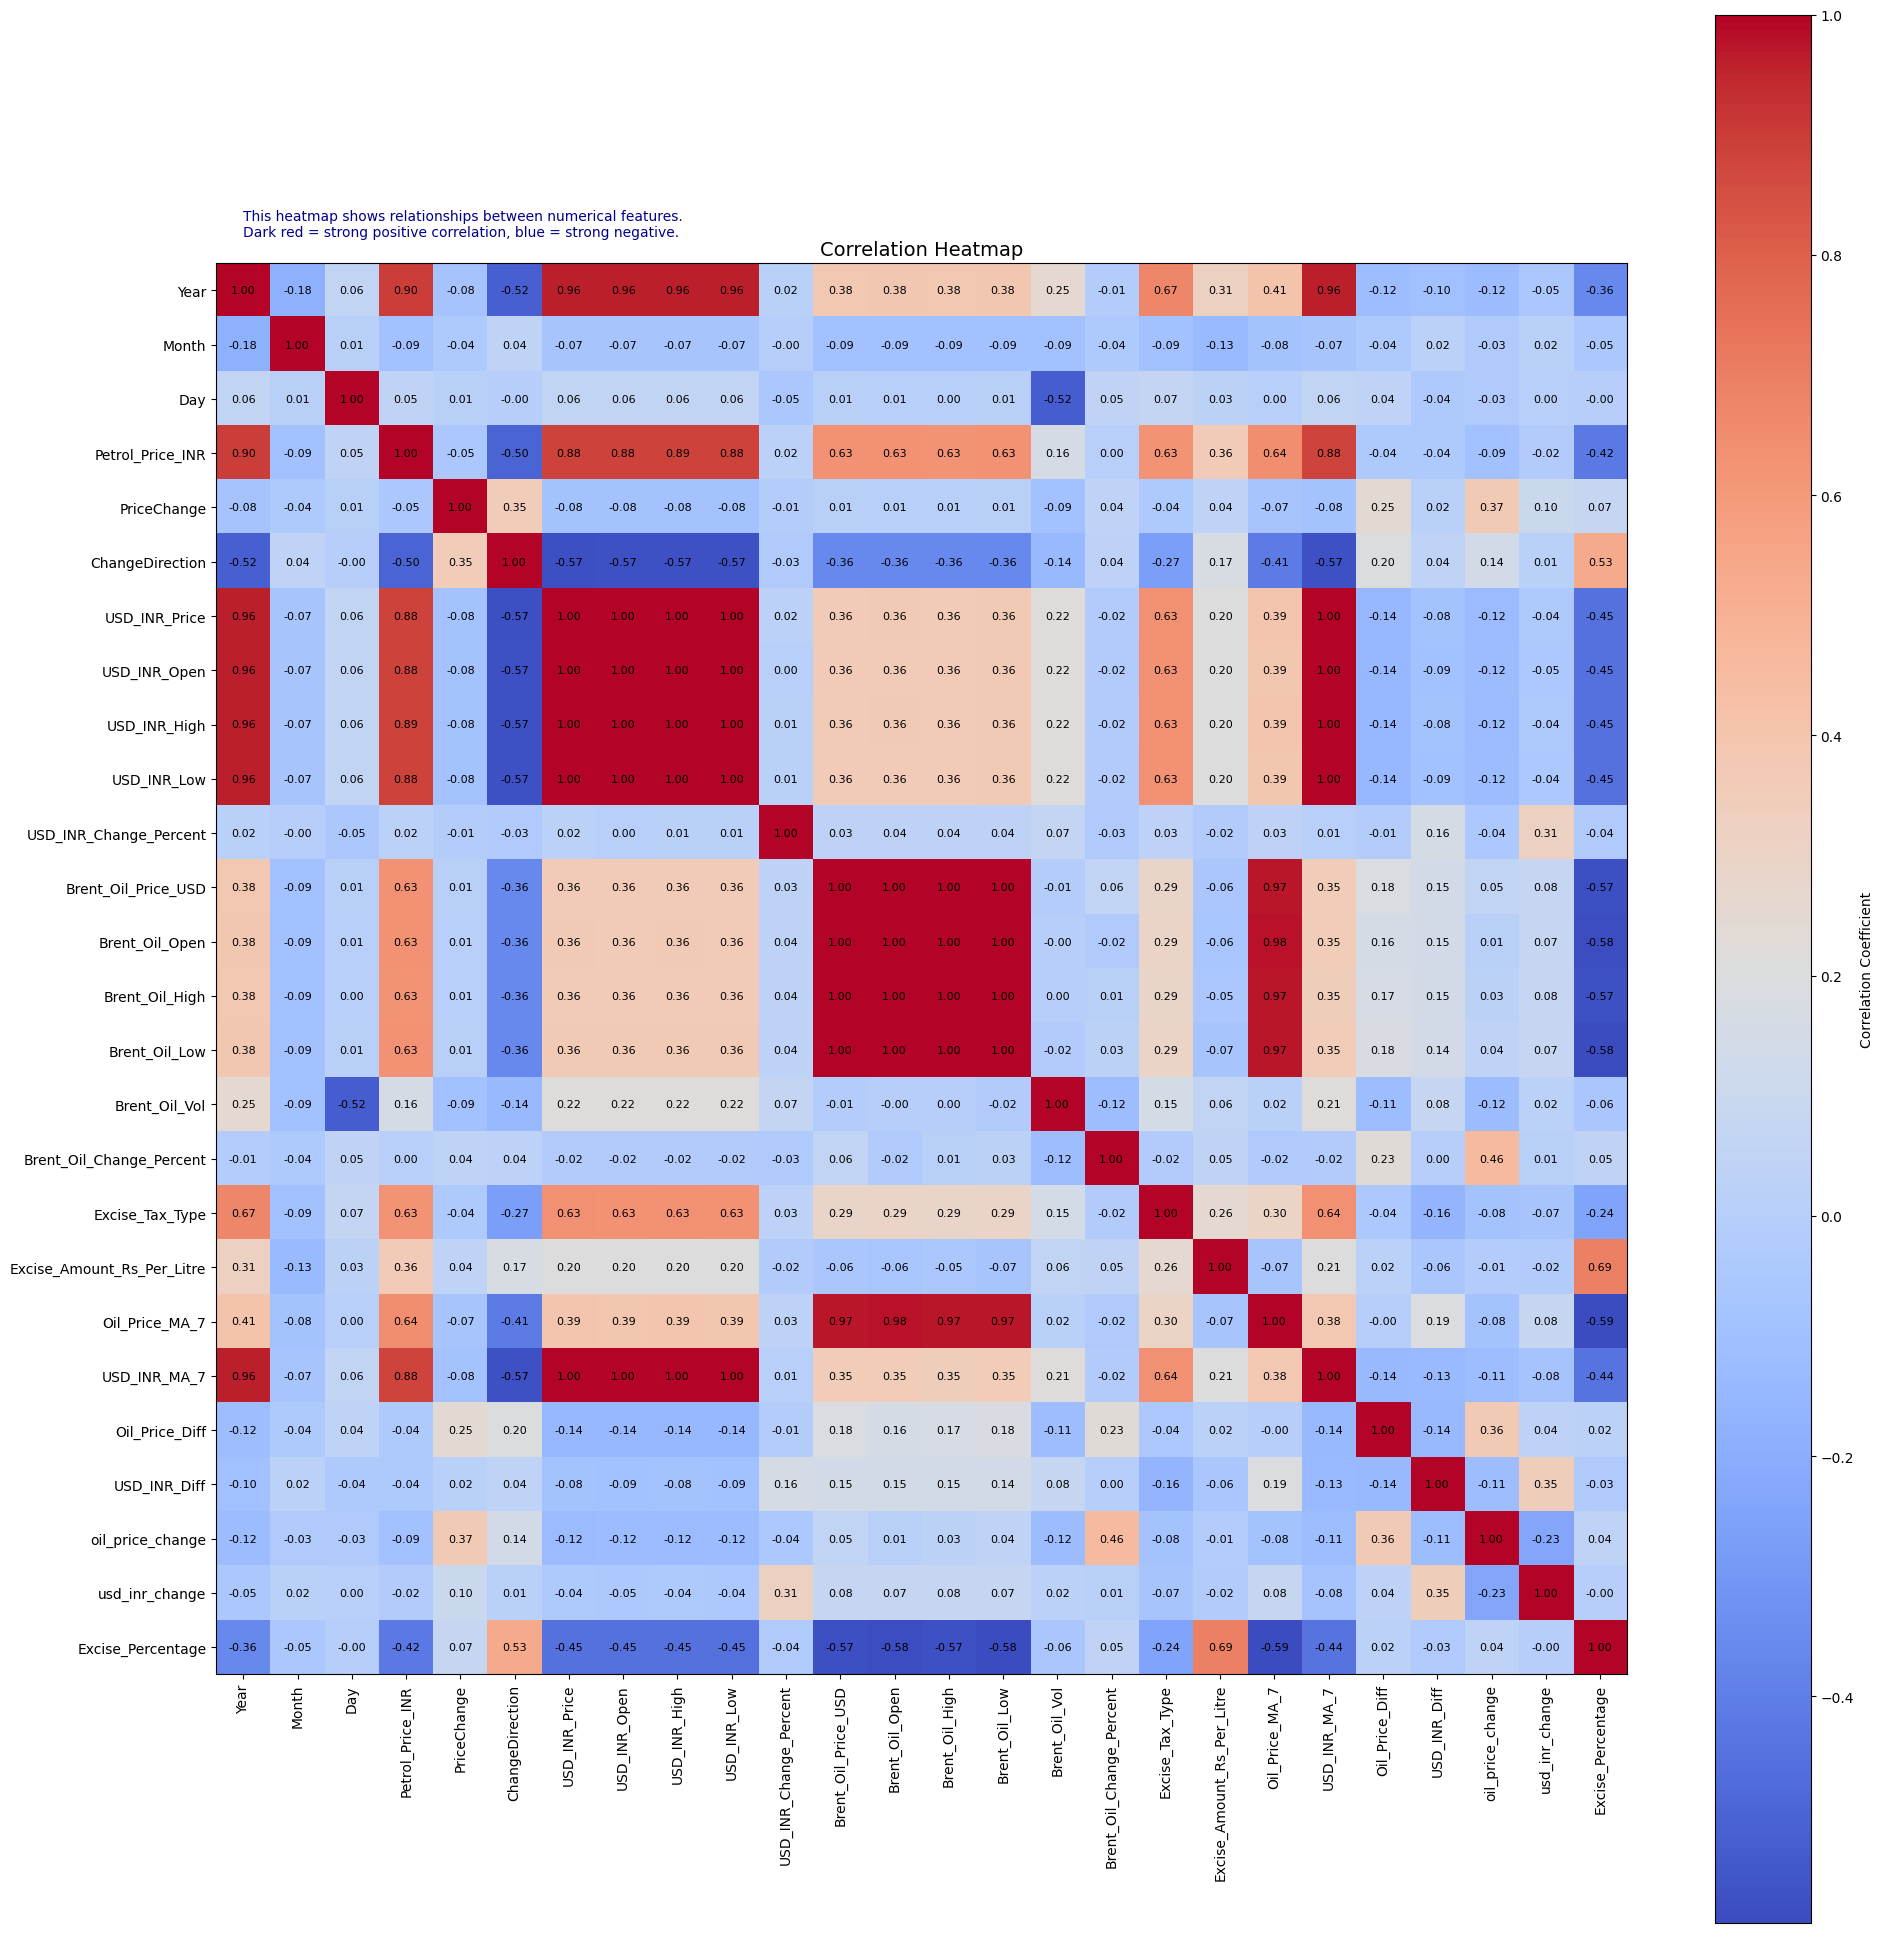

In [ ]:
import numpy as np

# Compute correlation matrix for numerical columns
corr = pp_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(20, 20))

# Heatmap with text
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values on top of squares
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = f"{corr.iloc[i, j]:.2f}"
        plt.text(j, i, text, ha='center', va='center', color='black', fontsize=8)

plt.title("Correlation Heatmap", fontsize=14)
plt.text(0, -1,
         "This heatmap shows relationships between numerical features.\nDark red = strong positive correlation, blue = strong negative.",
         fontsize=10, color='darkblue')

plt.tight_layout()
plt.show()


In [ ]:
pp_df.columns

Index(['Year', 'Month', 'Day', 'Date', 'Petrol_Price_INR', 'PriceChange',
       'ChangeDirection', 'USD_INR_Price', 'USD_INR_Open', 'USD_INR_High',
       'USD_INR_Low', 'USD_INR_Change_Percent', 'Brent_Oil_Price_USD',
       'Brent_Oil_Open', 'Brent_Oil_High', 'Brent_Oil_Low', 'Brent_Oil_Vol',
       'Brent_Oil_Change_Percent', 'Excise_Tax_Type',
       'Excise_Amount_Rs_Per_Litre', 'Oil_Price_MA_7', 'USD_INR_MA_7',
       'Oil_Price_Diff', 'USD_INR_Diff', 'oil_price_change', 'usd_inr_change',
       'Excise_Percentage'],
      dtype='object')

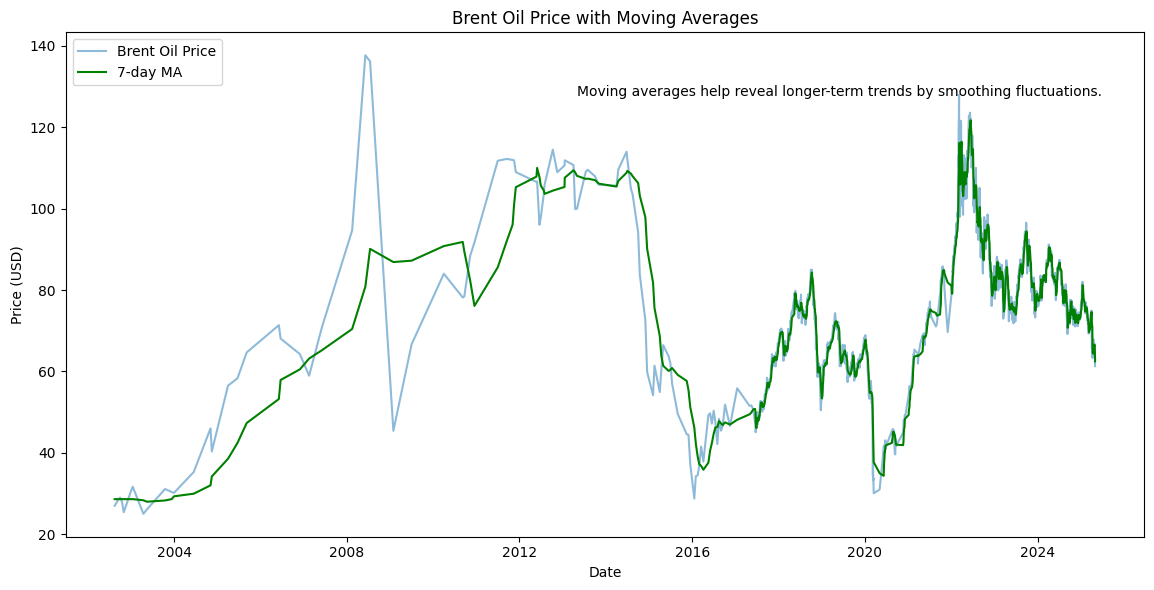

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(pp_df['Date'], pp_df['Brent_Oil_Price_USD'], label='Brent Oil Price', alpha=0.5)
plt.plot(pp_df['Date'], pp_df['Oil_Price_MA_7'], label='7-day MA', color='green')

plt.title("Brent Oil Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

plt.text(pp_df['Date'].iloc[50], max(pp_df['Brent_Oil_Price_USD']) - 10,
         "Moving averages help reveal longer-term trends by smoothing fluctuations.",
         )
plt.tight_layout()
plt.show()


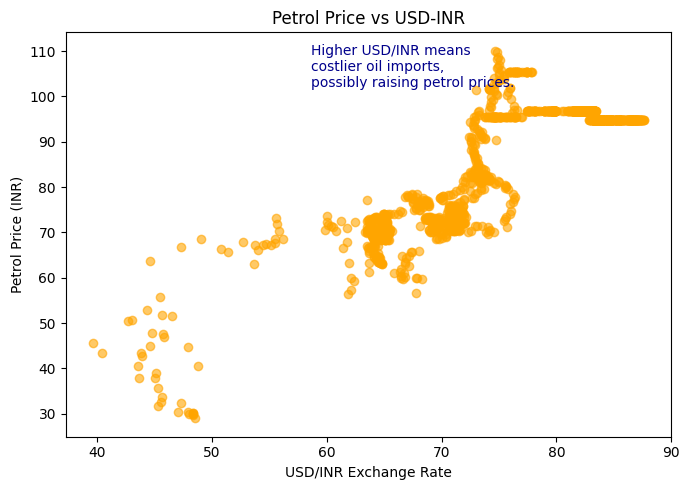

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(pp_df['USD_INR_Price'], pp_df['Petrol_Price_INR'], alpha=0.6, color='orange')
plt.title("Petrol Price vs USD-INR")
plt.xlabel("USD/INR Exchange Rate")
plt.ylabel("Petrol Price (INR)")
plt.text(min(pp_df['USD_INR_Price']) + 19, max(pp_df['Petrol_Price_INR']) - 8,
         "Higher USD/INR means \ncostlier oil imports, \npossibly raising petrol prices.", color='darkblue'
         )
plt.tight_layout()
plt.show()


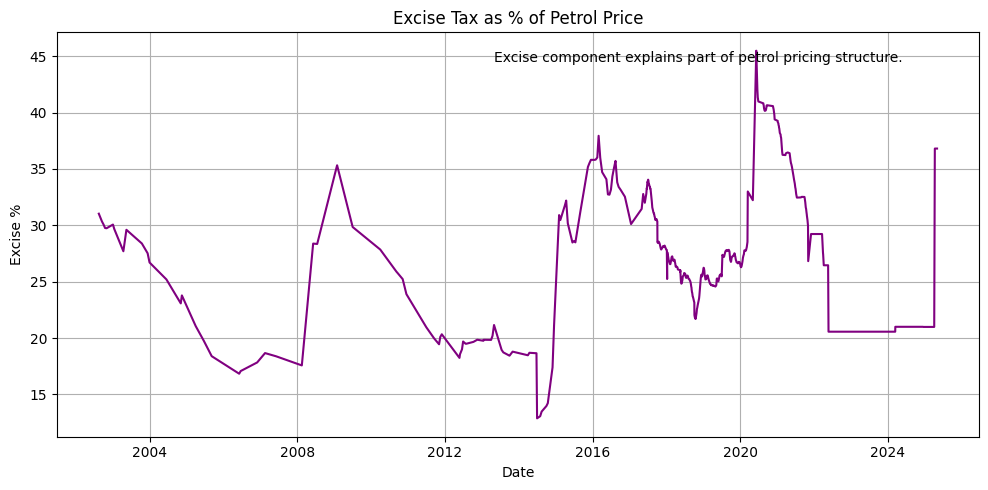

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(pp_df['Date'], pp_df['Excise_Percentage'], color='purple')
plt.title("Excise Tax as % of Petrol Price")
plt.xlabel("Date")
plt.ylabel("Excise %")
plt.grid(True)
plt.text(pp_df['Date'].iloc[50], max(pp_df['Excise_Percentage']) - 1,
         "Excise component explains part of petrol pricing structure.",
         )
plt.tight_layout()
plt.show()


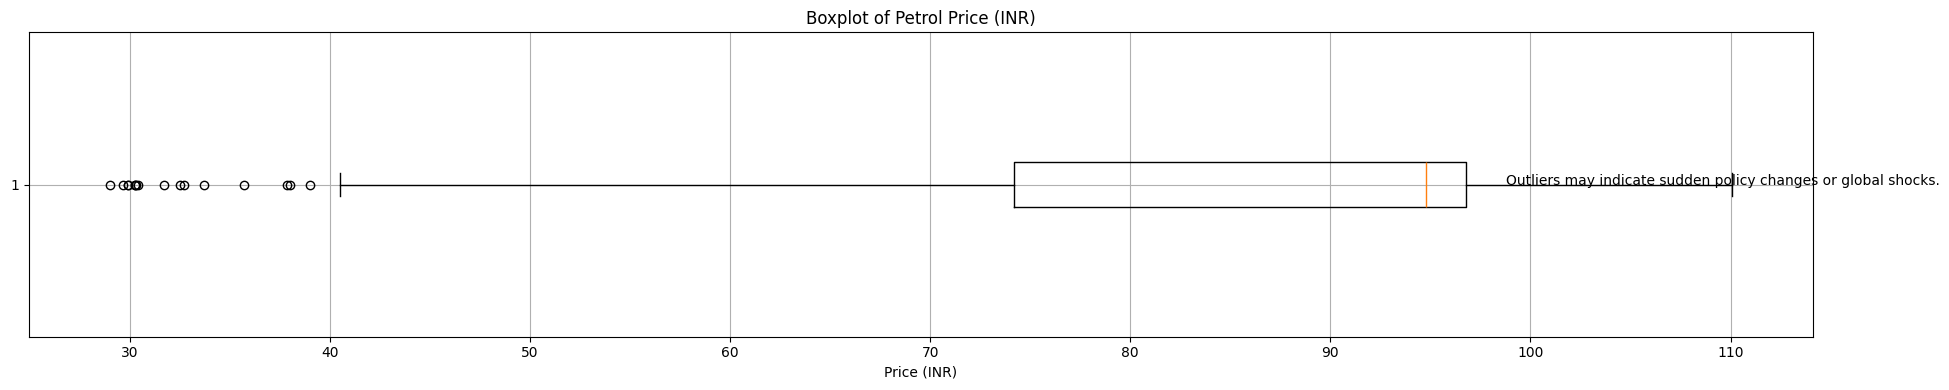

In [ ]:
plt.figure(figsize=(20, 4))
plt.boxplot(pp_df['Petrol_Price_INR'], vert=False)
plt.title("Boxplot of Petrol Price (INR)")
plt.xlabel("Price (INR)")
plt.grid(True)
plt.text(pp_df['Petrol_Price_INR'].quantile(0.75) + 2, 1,
         "Outliers may indicate sudden policy changes or global shocks.",
         )
plt.tight_layout()
plt.show()


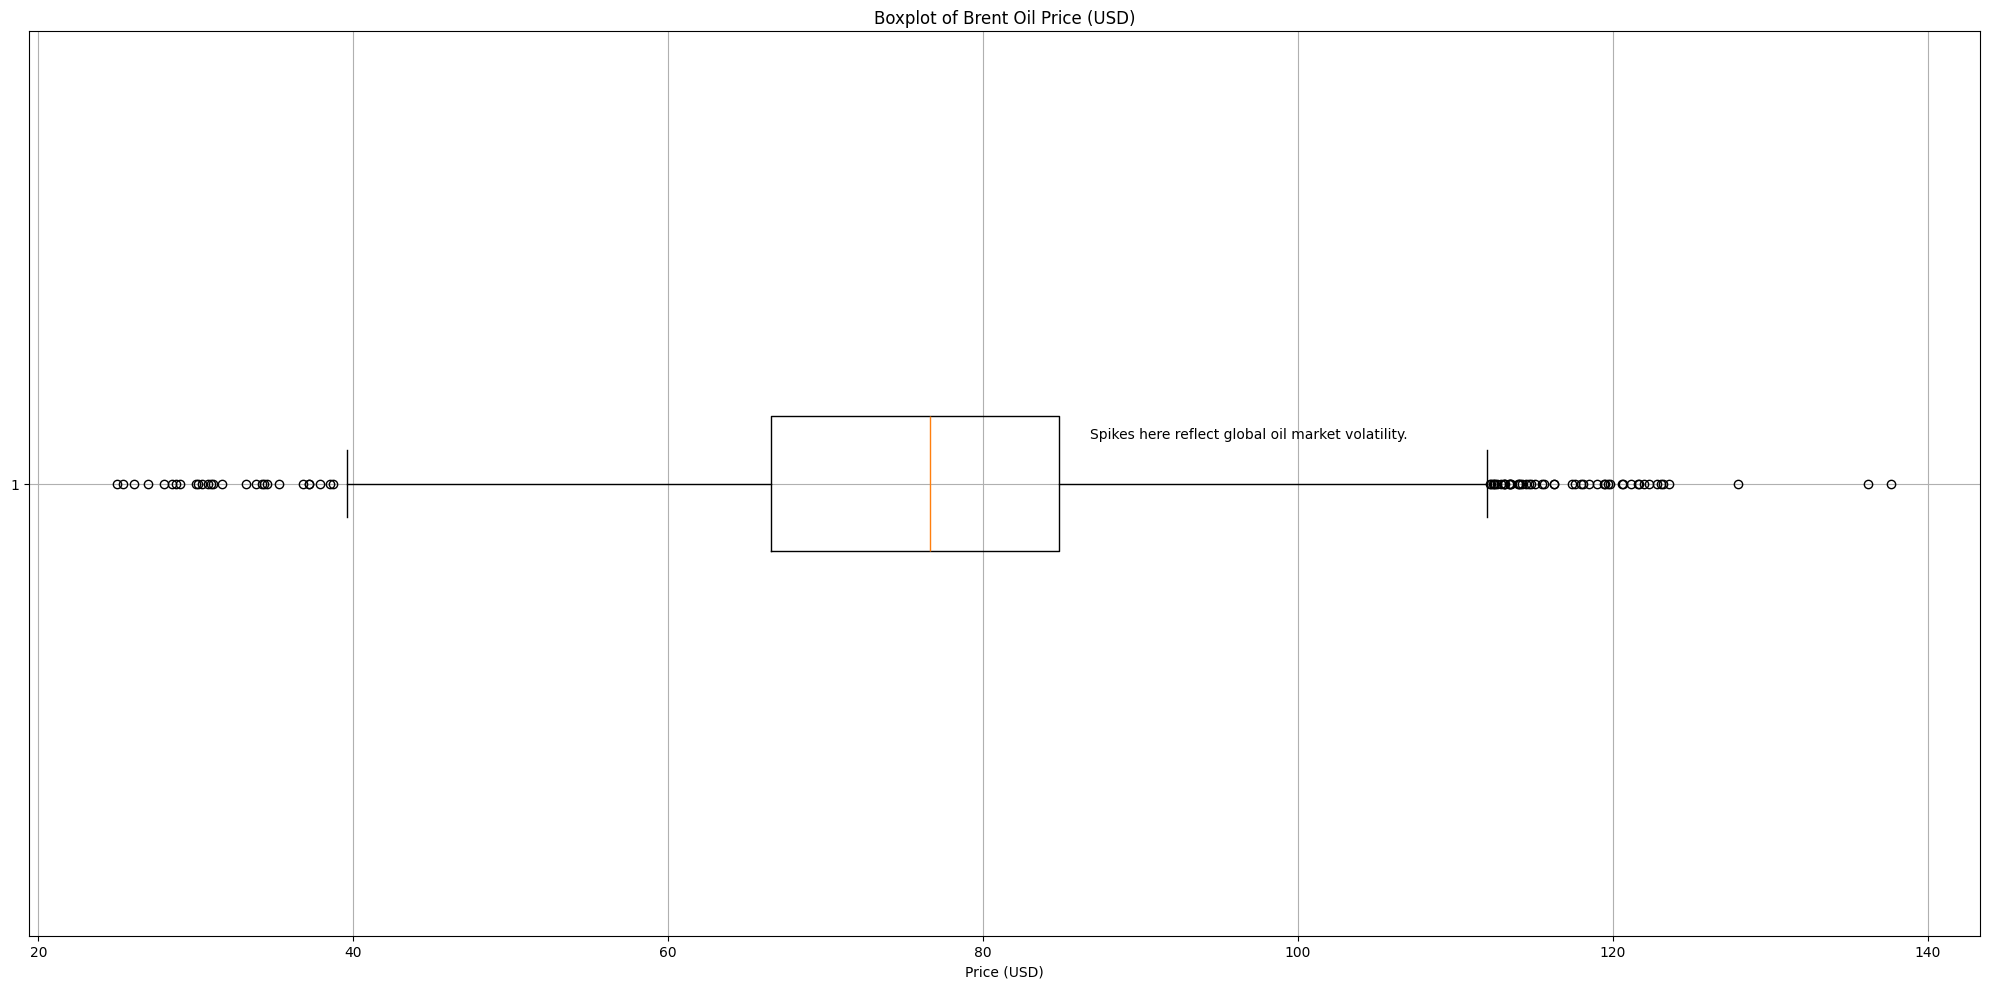

In [ ]:
plt.figure(figsize=(20, 10))
plt.boxplot(pp_df['Brent_Oil_Price_USD'], vert=False)
plt.title("Boxplot of Brent Oil Price (USD)")
plt.xlabel("Price (USD)")
plt.grid(True)
plt.text(pp_df['Brent_Oil_Price_USD'].quantile(0.75) + 2, 1.05,
         "Spikes here reflect global oil market volatility.",
         )
plt.tight_layout()
plt.show()


In [ ]:
X = pp_df.drop(['Petrol_Price_INR', 'Date'], axis=1)  # Drop target and date
y = pp_df['Petrol_Price_INR']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # Or try 'median'

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\nModel: {name}")
    print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
    print(f"MSE: {mean_squared_error(y_test, y_pred):.3f}")
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"RMSE: {rmse:.3f}")



Model: Linear Regression
R² Score: 0.984
MAE: 1.092
MSE: 2.397
RMSE: 1.548

Model: Random Forest
R² Score: 0.995
MAE: 0.265
MSE: 0.773
RMSE: 0.879

Model: Gradient Boosting
R² Score: 0.996
MAE: 0.420
MSE: 0.658
RMSE: 0.811
